In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier

In [146]:
df = pd.read_csv("Final.csv")
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,...,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,100.0,0.0,130.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,...,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,100.0,0.0,130.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,...,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,100.0,0.0,130.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,...,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,100.0,0.0,130.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,...,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,100.0,0.0,130.0,1.0


In [147]:
columns = df.columns
columns

Index(['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'TS1', 'TS2', 'TS3', 'TS4',
       'FS1', 'FS2', 'EPS1', 'VS1', 'CE', 'CP', 'SE', 'Cooler_Condition',
       'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator',
       'Stable_Flag'],
      dtype='object')

In [148]:
columns = columns.drop(['Cooler_Condition','Internal_Pump_Leakage', 'Valve_Condition', 'Hydraulic_Accumulator', 'Stable_Flag'])

In [149]:
df.describe()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,160.485315,109.379906,1.753227,2.600266,9.163320,9.079363,45.424567,50.365979,47.662121,40.735654,...,2495.509203,0.613315,31.299077,1.808399,55.287900,41.240816,90.693878,0.669388,107.199546,0.342857
std,4.699425,4.986585,0.251902,4.279355,0.576296,0.549589,7.991933,7.396254,7.451888,8.107878,...,73.836682,0.060260,11.575330,0.278263,8.960189,42.383143,10.681802,0.817233,16.435848,0.474772
min,155.391547,104.406307,0.840252,0.000000,8.365801,8.321527,35.313783,40.859400,38.245733,30.390800,...,2361.747267,0.524367,17.555983,1.062150,18.276617,3.000000,73.000000,0.000000,90.000000,0.000000
25%,158.100195,106.962382,1.729733,0.000000,8.547239,8.487167,36.237150,41.864183,39.123183,31.272567,...,2442.933467,0.555100,20.084650,1.550100,56.270183,3.000000,80.000000,0.000000,90.000000,0.000000
50%,158.960895,107.730169,1.779630,0.000000,9.115781,9.031516,44.836650,49.780583,47.070250,40.429050,...,2480.926633,0.610183,27.392533,1.739683,58.758150,20.000000,100.000000,0.000000,100.000000,0.000000
75%,161.000735,109.421612,1.932047,3.503266,9.844351,9.729276,54.104317,58.584467,55.694433,49.409500,...,2548.211467,0.649850,46.677383,2.148483,59.656900,100.000000,100.000000,1.000000,130.000000,1.000000
max,180.922708,131.589089,2.023398,10.207068,9.978511,9.856591,57.899283,61.958467,59.423167,53.060417,...,2740.641000,0.839067,47.903667,2.840100,60.755300,100.000000,100.000000,2.000000,130.000000,1.000000


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PS1                    2205 non-null   float64
 1   PS2                    2205 non-null   float64
 2   PS3                    2205 non-null   float64
 3   PS4                    2205 non-null   float64
 4   PS5                    2205 non-null   float64
 5   PS6                    2205 non-null   float64
 6   TS1                    2205 non-null   float64
 7   TS2                    2205 non-null   float64
 8   TS3                    2205 non-null   float64
 9   TS4                    2205 non-null   float64
 10  FS1                    2205 non-null   float64
 11  FS2                    2205 non-null   float64
 12  EPS1                   2205 non-null   float64
 13  VS1                    2205 non-null   float64
 14  CE                     2205 non-null   float64
 15  CP  

<Axes: xlabel='Internal_Pump_Leakage', ylabel='count'>

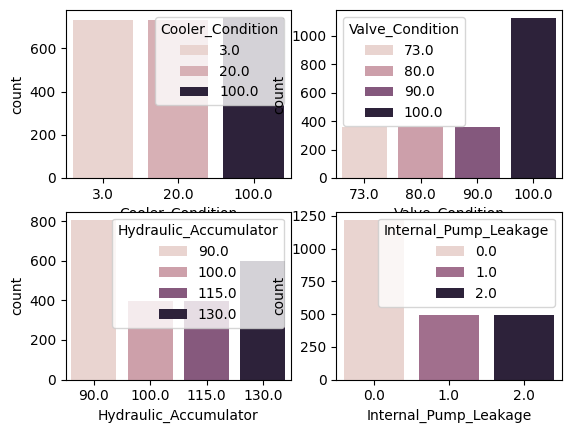

In [151]:
plt.subplot(2,2,1)
sns.countplot(x='Cooler_Condition', data=df, hue='Cooler_Condition')
plt.subplot(2,2,2)
sns.countplot(x='Valve_Condition', data=df, hue='Valve_Condition')
plt.subplot(2,2,3)
sns.countplot(x='Hydraulic_Accumulator', data=df, hue='Hydraulic_Accumulator')
plt.subplot(2,2,4)
sns.countplot(x='Internal_Pump_Leakage', data=df, hue='Internal_Pump_Leakage')

<Axes: xlabel='Internal_Pump_Leakage', ylabel='count'>

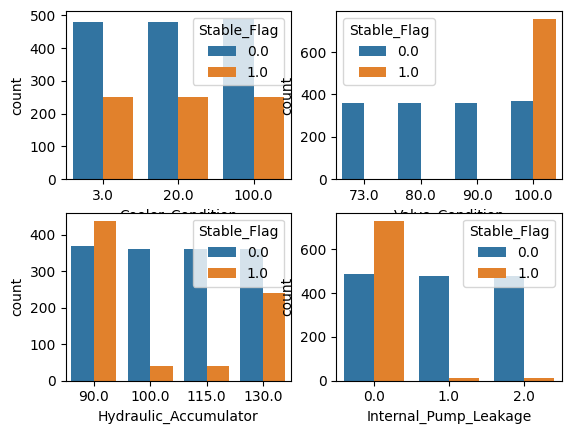

In [152]:
plt.subplot(2,2,1)
sns.countplot(x='Cooler_Condition', data=df, hue='Stable_Flag')
plt.subplot(2,2,2)
sns.countplot(x='Valve_Condition', data=df, hue='Stable_Flag')
plt.subplot(2,2,3)
sns.countplot(x='Hydraulic_Accumulator', data=df, hue='Stable_Flag')
plt.subplot(2,2,4)
sns.countplot(x='Internal_Pump_Leakage', data=df, hue='Stable_Flag')

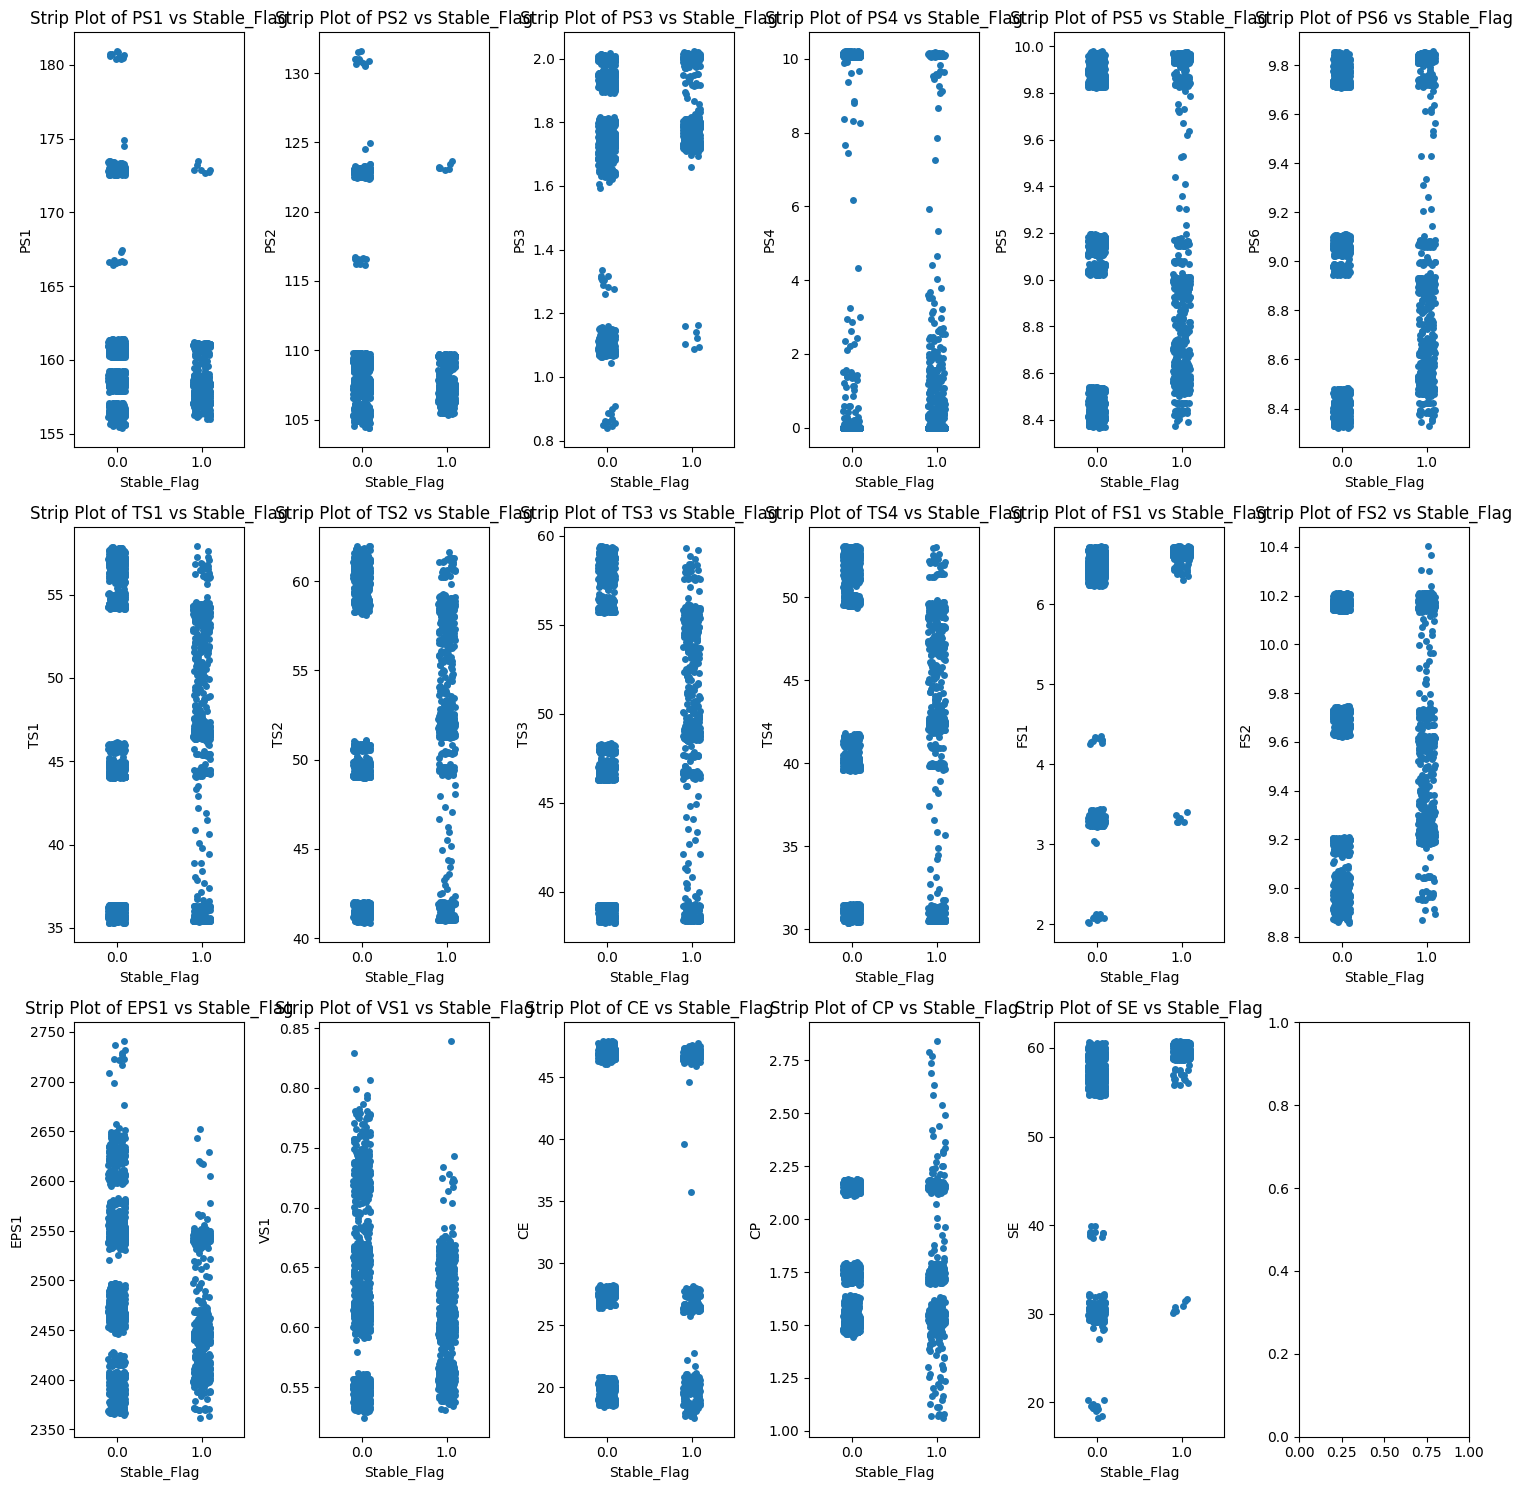

In [153]:
row = 6
col = 3
fig, ax = plt.subplots(col, row, figsize=(15, 15))
ax = ax.flatten()
for i, col in enumerate(columns):
    sns.stripplot(x='Stable_Flag', y=col, data=df, ax=ax[i])
    ax[i].set_title(f'Strip Plot of {col} vs Stable_Flag')

plt.tight_layout()


<Axes: >

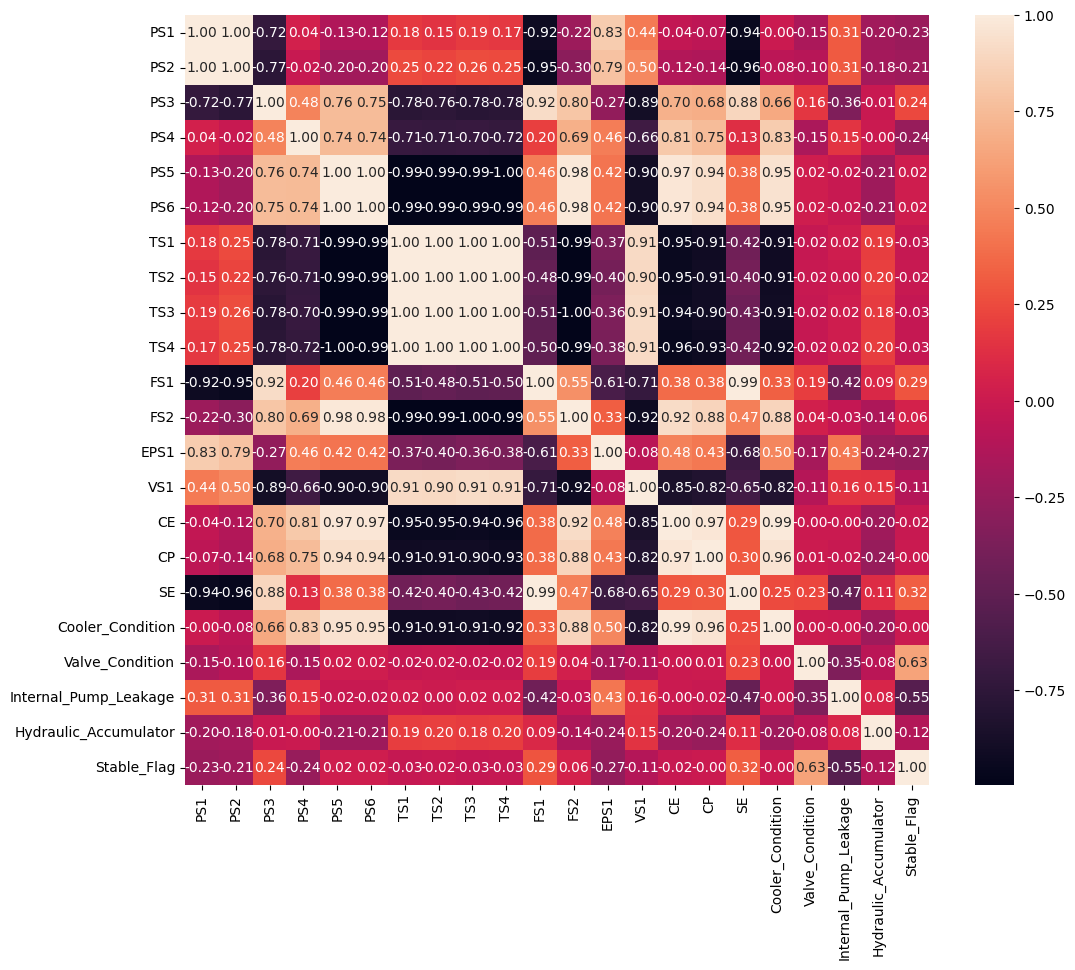

In [154]:
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f")

In [ ]:
df.tail()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,...,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,100.0,0.0,130.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,...,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,100.0,0.0,130.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,...,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,100.0,0.0,130.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,...,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,100.0,0.0,130.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,...,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,100.0,0.0,130.0,1.0


In [156]:
df_cooler = df.drop(['Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator'], axis=1)
df_cooler.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,6.709815,10.304592,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,6.715315,10.403098,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,6.718522,10.366250,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,6.720565,10.302678,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,6.690308,10.237750,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,1.0


In [157]:
columns

Index(['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'TS1', 'TS2', 'TS3', 'TS4',
       'FS1', 'FS2', 'EPS1', 'VS1', 'CE', 'CP', 'SE'],
      dtype='object')

In [158]:
scaler = StandardScaler()
df_cooler[columns] = scaler.fit_transform(df_cooler[columns])
df_cooler.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Stable_Flag
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,0.495101,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,3.0,1.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,0.500427,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,3.0,1.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,0.503533,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,3.0,1.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,0.505511,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,3.0,1.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,0.476211,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,3.0,1.0


In [159]:
df_cooler['Cooler_Condition'].value_counts()

Cooler_Condition
100.0    741
3.0      732
20.0     732
Name: count, dtype: int64

In [160]:
le = LabelEncoder()
df_cooler['Cooler_Condition'] = le.fit_transform(df_cooler['Cooler_Condition'])
df_cooler.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Stable_Flag
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,0.495101,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,0,1.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,0.500427,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,0,1.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,0.503533,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,0,1.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,0.505511,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,0,1.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,0.476211,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,0,1.0


In [161]:
df_cooler['Cooler_Condition'].value_counts()

Cooler_Condition
2    741
0    732
1    732
Name: count, dtype: int64

In [162]:
X = df_cooler.drop('Cooler_Condition', axis=1)
y = df_cooler['Cooler_Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [163]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1764, 18), (441, 18), (1764,), (441,))

In [164]:
sgdr = SGDClassifier()
sgdr.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [165]:
sgdr.score(X_test, y_test)

1.0

In [166]:
X_train

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Stable_Flag
1050,-0.382563,-0.361354,0.186199,-0.607768,-0.180900,-0.183410,0.027561,0.031197,0.023245,0.045570,0.461298,0.023675,-0.583793,0.020494,-0.285788,-0.203745,0.535439,0.0
1967,-0.045179,-0.090664,0.699680,1.745329,1.175014,1.175904,-1.139086,-1.143781,-1.134051,-1.154140,0.203595,1.116132,0.797853,-1.293562,1.345681,1.200103,0.072736,0.0
1387,-0.348129,-0.449251,-0.034439,-0.607768,-0.002433,-0.003729,-0.166773,-0.174857,-0.173267,-0.127109,0.206636,0.142583,-0.338116,-0.099293,-0.336874,-0.230525,0.156390,0.0
1639,0.122591,0.042748,0.989230,-0.003901,1.392827,1.394968,-1.251977,-1.260675,-1.244402,-1.263238,0.470663,1.250435,0.708309,-1.097422,1.355617,1.302428,0.385682,1.0
1652,0.118427,0.039601,0.988804,-0.502620,1.349316,1.351850,-1.240726,-1.256132,-1.238809,-1.253928,0.478506,1.214567,0.632335,-0.967123,1.357175,1.267980,0.420233,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0.122283,0.046133,0.963384,0.014748,1.387575,1.388026,-1.252153,-1.262147,-1.244726,-1.266353,0.472504,1.240405,0.703847,-1.098805,1.372206,1.334779,0.398493,1.0
1095,-0.483828,-0.489879,-0.099460,-0.607768,-0.088273,-0.093456,-0.066956,-0.070993,-0.065581,-0.027651,0.153807,0.102922,-0.152652,-0.114508,-0.302892,-0.240589,0.078349,0.0
1130,-0.413560,-0.440804,0.021105,-0.607768,-0.055096,-0.056607,-0.083610,-0.085970,-0.083768,-0.043079,0.258348,0.097891,-0.295107,0.172371,-0.329083,-0.255926,0.234840,0.0
1294,-0.265283,-0.397430,0.144871,-0.605605,-0.004680,-0.007710,-0.146051,-0.147808,-0.156614,-0.113173,0.418354,0.166981,-0.375784,-0.164857,-0.338683,-0.209077,0.384664,0.0


In [169]:
# Separate raw input (without stable_val) and scale it
list = [174.89, 124.5, 1.04, 0.0, 8.54, 8.48, 2676.66, 3.02, 9.2, 54.14, 58.59, 55.78, 49.56, 0.74, 19.97, 1.54, 27.13]
raw_input_features = np.array(list).reshape(1, -1)
scaled_input = scaler.transform(raw_input_features)
print(scaled_input)

stable_val = 1
# Combine scaled input with stable_val
final_input = np.hstack((scaled_input, [[stable_val]]))  # ensure it's 2D

[[  3.06589727   3.03284154  -2.83201429  -0.60776822  -1.08184186
   -1.09081211 329.31108739  -6.40279731  -5.16256367   1.65362457
   50.73502594 102.70775311 -33.13399198   2.10278741  -0.97894805
   -0.96476989  -3.14326915]]


c:\Users\Rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [170]:
cooler_status = sgdr.predict(final_input)[0]
cooler_status

c:\Users\Rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


np.int64(0)